In [1]:
using CellularSheaves
using CliqueTrees.Multifrontal
using LinearAlgebra
using Plots
using SparseArrays

F is a cellular sheaf

In [2]:
n = 6; stalk_dim = 3

F = EuclideanSheaf{Float64}(Int[])

for i in 1:n
    add_vertex_stalk!(F, stalk_dim)
end

for i in 1:n
    v1 = i
    v2 = (i % n) + 1
    rm = Matrix{Float64}(I, stalk_dim, stalk_dim)
    add_sheaf_edge!(F, v1, v2, rm, rm)
end

X is the Laplacian of F

In [3]:
C = sparse(coboundary_map(F))
X = C' * C

18×18 SparseArrays.SparseMatrixCSC{Float64, Int64} with 162 stored entries:
⎡⣿⣿⣿⣀⡀⠀⠀⠸⠿⎤
⎢⠛⢻⣿⣿⣧⣤⠀⠀⠀⎥
⎢⠀⠈⠉⣿⣿⣿⣶⡆⠀⎥
⎢⣀⡀⠀⠀⠸⠿⣿⣿⣿⎥
⎣⠛⠃⠀⠀⠀⠀⠛⠛⠛⎦

M is an LDLt factorization of X

$$
  X = P^\mathsf{T} L D L^\mathsf{T} P
$$

In [4]:
M = ldlt!(ChordalLDLt(X), RowMaximum())

L = M.L # lower triangular factor
D = M.D # diagonal factor
P = M.P # permutation

L

18×18 FChordalTriangular{:U, :L, Float64, Int64} with 162 stored entries:
⎡⠷⢄⠀⠀⠀⠀⠀⠀⠀⎤
⎢⣤⣼⣷⣄⠀⠀⠀⠀⠀⎥
⎢⠉⠉⠉⠉⢱⣄⠀⠀⠀⎥
⎢⠛⢣⣤⣿⣿⣿⣷⣄⠀⎥
⎣⠒⠊⠉⠛⠛⠛⠛⠛⠓⎦

V is a basis for the nullspace of X

In [5]:
max_abs_diag = maximum(i -> abs(D[i, i]), 1:size(D, 1); init=0.0)
tol = eps(Float64) * max(1.0, max_abs_diag)
ind = findall(i -> abs(D[i, i]) <= tol, 1:size(D, 1))
U = zeros(size(D, 1), length(ind))

for j in eachindex(ind)
    U[ind[j], j] = 1
end

V = P \ (L' \ U)

18×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

Visualize the nullspace basis: each column of V is plotted as a separate scatter series.

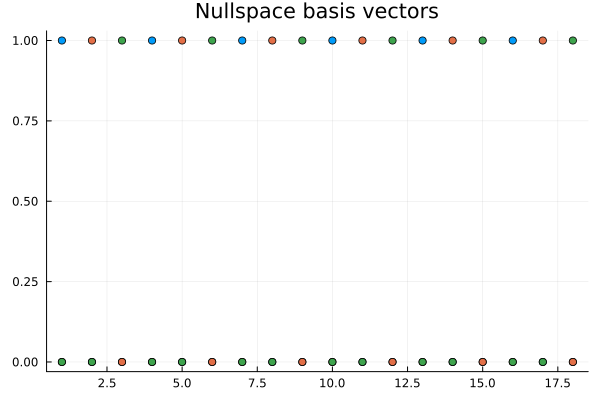

In [6]:
scatter(V, legend=false, title="Nullspace basis vectors")